# N-Grams

It's a probabilistic model that's trained on a corpus of text. Such a model is useful in many NLP applications including speech recognition, machine translation and predictive text input. An N-gram model is built by counting how often word sequences occur in corpus text and then estimating the probabilities.

## Types of N-Grams

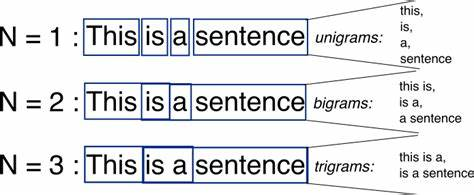

## Use-cases of N-Grams

- Auto completion of sentences
- Auto spell check
- Voice-based personal assistant bots

## Unigram

**Unigram** an n-gram consisting of a single item from a sequence.

- It is commonly used to calculate the probability of finding a word in an article.

$ count of (A) \div corpus length $

In [ ]:
from nltk.util import ngrams
from nltk.tokenize import word_tokenize

string = "moses supposes his toeses are roses but moses supposes erroneously"

unigrams = ngrams(word_tokenize(string), 1)

for item in unigrams:
    print(item)

('moses',)
('supposes',)
('his',)
('toeses',)
('are',)
('roses',)
('but',)
('moses',)
('supposes',)
('erroneously',)


### Calculating probabilities in unigram models

In [ ]:
### Calculate counts of each word

unique_string = set(word_tokenize(string))

words_frq = []
for uniques in unique_string:
    frq = string.count(uniques)
    words_frq.append((uniques, frq))

words_frq

[('toeses', 1),
 ('are', 1),
 ('roses', 1),
 ('his', 1),
 ('but', 1),
 ('erroneously', 1),
 ('supposes', 2),
 ('moses', 2)]

In [ ]:
### Calculate probabilities:

probab = []

for count in range(len(words_frq)):
    pro = words_frq[count][1]/len(string)
    probab.append(pro)

print('the probabilities are: ',probab)

the probabilities are:  [0.015151515151515152, 0.015151515151515152, 0.015151515151515152, 0.015151515151515152, 0.015151515151515152, 0.015151515151515152, 0.030303030303030304, 0.030303030303030304]


In [ ]:
probabilities = []
for i,j in zip(unique_string, probab):
    probabilities.append((i,j))
probabilities

[('toeses', 0.015151515151515152),
 ('are', 0.015151515151515152),
 ('roses', 0.015151515151515152),
 ('his', 0.015151515151515152),
 ('but', 0.015151515151515152),
 ('erroneously', 0.015151515151515152),
 ('supposes', 0.030303030303030304),
 ('moses', 0.030303030303030304)]

## Bigram

**Bigram** an n-gram consisting of two items from a sequence
- Two words that are used together to mean something specific

$ countof(A \ then \ B) \div countof(A) $

### Method 1

In [ ]:
import nltk as nl
from nltk.tokenize import word_tokenize

string = "moses supposes his toeses are roses but moses supposes erroneously"

bigrams = nl.bigrams(word_tokenize(string))
for i in bigrams:
    print(i)


('moses', 'supposes')
('supposes', 'his')
('his', 'toeses')
('toeses', 'are')
('are', 'roses')
('roses', 'but')
('but', 'moses')
('moses', 'supposes')
('supposes', 'erroneously')


### Method 2

In [ ]:
from nltk.util import ngrams
from nltk.tokenize import word_tokenize

string = "moses supposes his toeses are roses but moses supposes erroneously"

bigrams = ngrams(word_tokenize(string),2)

for i in bigrams:
    print(i)

('moses', 'supposes')
('supposes', 'his')
('his', 'toeses')
('toeses', 'are')
('are', 'roses')
('roses', 'but')
('but', 'moses')
('moses', 'supposes')
('supposes', 'erroneously')


# Trigram

**Trigram** an n-gram consisting of three items of a sequence
- Three words that are used together to mean something specific

### Method 1

In [ ]:
import nltk as nl
from nltk.tokenize import word_tokenize

string = "moses supposes his toeses are roses but moses supposes erroneously"

trigrams = nl.trigrams(word_tokenize(string))

for i in trigrams:
    print(i)


('moses', 'supposes', 'his')
('supposes', 'his', 'toeses')
('his', 'toeses', 'are')
('toeses', 'are', 'roses')
('are', 'roses', 'but')
('roses', 'but', 'moses')
('but', 'moses', 'supposes')
('moses', 'supposes', 'erroneously')


### Method 2

In [ ]:
from nltk.util import ngrams
from nltk.tokenize import word_tokenize

string = "moses supposes his toeses are roses but moses supposes erroneously"

trigrams = ngrams(word_tokenize(string),3)

for i in trigrams:
    print(i)


('moses', 'supposes', 'his')
('supposes', 'his', 'toeses')
('his', 'toeses', 'are')
('toeses', 'are', 'roses')
('are', 'roses', 'but')
('roses', 'but', 'moses')
('but', 'moses', 'supposes')
('moses', 'supposes', 'erroneously')


## What is padding in NLP?

padding is a technique used to ensure that all input sequences have the same length. This is necessary because neural networks require inputs that have the same shape and size. However, when we pre-process and use texts as inputs for our model, not all sentences have the same length. In other words, some sentences are longer or shorter than others. We need to have inputs with the same size, and this is where padding comes in 1.

Padding is a special form of masking where the masked steps are at the start or the end of a sequence. Padding comes from the need to encode sequence data into contiguous batches: in order to make all sequences in a batch fit a given standard length.
The padding is added before splitting the sentence.

n-1 padding is added.



In [ ]:
from nltk.util import ngrams
from nltk.tokenize import word_tokenize


string = "moses supposes his toeses are roses but moses supposes erroneously"

list(ngrams(word_tokenize(string), pad_left=True, left_pad_symbol="<s>",
                                pad_right=True, right_pad_symbol="</s>", n=2))

[('<s>', 'moses'),
 ('moses', 'supposes'),
 ('supposes', 'his'),
 ('his', 'toeses'),
 ('toeses', 'are'),
 ('are', 'roses'),
 ('roses', 'but'),
 ('but', 'moses'),
 ('moses', 'supposes'),
 ('supposes', 'erroneously'),
 ('erroneously', '</s>')]

Alternatively, We can get rid of the parameters by using
> pad_both_ends method in NLTK

**Note the n argument, that tells the function we need padding for bigrams.**

In [ ]:
from nltk.lm.preprocessing import pad_both_ends
from nltk.util import ngrams
from nltk.tokenize import word_tokenize

string = "moses supposes his toeses are roses but moses supposes erroneously"

list(ngrams(pad_both_ends(word_tokenize(string), n=2), n=2))


[('<s>', 'moses'),
 ('moses', 'supposes'),
 ('supposes', 'his'),
 ('his', 'toeses'),
 ('toeses', 'are'),
 ('are', 'roses'),
 ('roses', 'but'),
 ('but', 'moses'),
 ('moses', 'supposes'),
 ('supposes', 'erroneously'),
 ('erroneously', '</s>')]

### Training the Maximum Likelihood Model

Maximum likelihood estimation estimates the model parameters such that the probability is maximized.

- Get the requisite n_grams frequency counts from a corpus.

- Normalize them to a 0-1 range.

- Build the vocabulary: to create this vocabulary we need to pad our sentences (just like for counting ngrams) and then combine the sentences into one flat stream of words.


To do the above steps, we need to create and Ngram and add the padding then flatten the list. All these steps are requested for pre-processing to train the MLE model. However, we can use padded_everygram_pipeline() in NLTK to do all the steps in one call.


**References:**

https://www.nltk.org/api/nltk.lm.html

https://www.kaggle.com/code/alvations/n-gram-language-model-with-nltk

In [ ]:
from nltk.lm.preprocessing import padded_everygram_pipeline
from nltk.util import ngrams
from nltk.tokenize import word_tokenize
from nltk.lm import smoothing

string = "moses supposes his toeses are roses but moses supposes erroneously"

#Create Bigram Language Model
train, vocab = padded_everygram_pipeline(2, [word_tokenize(string)])

In [ ]:
from nltk.lm import MLE
lm = MLE(2)
lm.fit(train, vocab) #Train the Maximum Likelihood Model
print(lm.vocab)
print(len(lm.vocab))

<Vocabulary with cutoff=1 unk_label='<UNK>' and 11 items>
11


In [ ]:
lm.vocab.lookup(['moses','supposes'])

('moses', 'supposes')

In [ ]:
lm.vocab.lookup(['moses'])

('moses',)

### counts for unigrams and bigrams

In [ ]:
print(lm.counts['moses'])
# a then b
print(lm.counts[['moses']]['supposes'])

2
2


In [ ]:
print(lm.score('moses')) #Calculate Bigram Probabilities

0.16666666666666666


Here’s how you get the score for a word given some preceding context. For example we want to know what is the chance that “b” is preceded by “a”.

In [ ]:
# b then a
lm.score("supposes", ["moses"])

1.0

### Evaluating n_grams models using preplexity

**Preplexity** is the probability of the test set normalized by the number of words

In [ ]:
test = [('moses', 'supposes'), ('toeses','are')]
print(lm.perplexity(test))

1.0


## Task: Generating tweets using n_grams

In this Task, we will build a MLE model with n-gram to generate tweets.

The agenda is:
1. load the data:
https://www.kaggle.com/datasets/adizafar/large-random-tweets-from-pakistan

2. pre-processing the data:
*   Remove hashtags
*   Remove RT
*   Remove any website
*   Remove any mentions




3. build MLE model with n-gram
4. evaluate the model

before we start we need to install library to handle the emojis in tweets
> pip install emoji

### Step 0: Install and import dependencies


In [ ]:
import re
import random
import subprocess
import sys
import pandas as pd

try:
    import emoji
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "emoji"])
    import emoji

from nltk.lm.preprocessing import padded_everygram_pipeline
from nltk.lm import MLE


def simple_tokenize(text):
    """Lightweight regex tokenizer (avoids extra corpus downloads)."""
    return re.findall(r"[a-z']+", text.lower())


### Step 1: Load the data

Download the CSV from [Kaggle: Large Random Tweets from Pakistan](https://www.kaggle.com/datasets/adizafar/large-random-tweets-from-pakistan) and place it next to this notebook as `tweets.csv`. If the file isn't found, a small demo sample is used instead so the notebook still runs end-to-end.


In [2]:
try:
    df = pd.read_csv("tweets.csv")
    text_col = "text" if "text" in df.columns else df.columns[0]
    tweets = df[text_col].astype(str).tolist()
    print(f"Loaded {len(tweets)} tweets from tweets.csv")
except FileNotFoundError:
    print("tweets.csv not found locally - using a small demo sample instead.")
    tweets = [
        "RT @user123: Pakistan is a beautiful country! #travel https://t.co/abc123",
        "I love visiting Pakistan, Pakistan is amazing!! @friend check this out",
        "Pakistan is growing fast, the economy of Pakistan is improving #economy",
        "RT @news: Pakistan is hosting a big cricket match today https://t.co/xyz789",
        "@someone Pakistan is my home country and I am proud of it!!! 🇵🇰",
        "The weather in Pakistan is very hot this summer #weather https://t.co/weather1",
        "Pakistan is known for its hospitality, Pakistan is truly special ❤️",
        "RT @sports: cricket in Pakistan is loved by everyone #cricket",
        "Pakistan is a nuclear power and Pakistan is proud of its army @official",
        "I think Pakistan is one of the friendliest nations on earth!! 😊 https://t.co/link2",
    ] * 5

tweets[:3]


tweets.csv not found locally - using a small demo sample instead.


['RT @user123: Pakistan is a beautiful country! #travel https://t.co/abc123',
 'I love visiting Pakistan, Pakistan is amazing!! @friend check this out',
 'Pakistan is growing fast, the economy of Pakistan is improving #economy']

### Step 2: Pre-process the data

- Remove hashtags
- Remove RT
- Remove any website
- Remove any mentions
- Remove emojis
- Remove extra symbols and extra spaces
- Lowercase everything


In [3]:
def clean_tweet(t):
    t = emoji.replace_emoji(t, replace="")   # remove emojis
    t = re.sub(r"^RT\s+", "", t)              # remove RT
    t = re.sub(r"@\w+", "", t)                # remove mentions
    t = re.sub(r"#\w+", "", t)                # remove hashtags
    t = re.sub(r"http\S+|www\.\S+", "", t)    # remove websites
    t = re.sub(r"[^A-Za-z\s]", " ", t)         # remove extra symbols
    t = re.sub(r"\s+", " ", t).strip().lower() # remove extra spaces + lowercase
    return t


cleaned_tweets = [clean_tweet(t) for t in tweets]
cleaned_tweets = [t for t in cleaned_tweets if t]
tokenized_tweets = [simple_tokenize(t) for t in cleaned_tweets]

print("Before:", tweets[0])
print("After :", cleaned_tweets[0])
print("Tokens:", tokenized_tweets[0])


Before: RT @user123: Pakistan is a beautiful country! #travel https://t.co/abc123
After : pakistan is a beautiful country
Tokens: ['pakistan', 'is', 'a', 'beautiful', 'country']


### Step 3: Build the MLE n-gram model

We train an order-3 model so unigram, bigram and trigram counts/probabilities are all available from the same model.


In [4]:
n = 3
train_data, padded_vocab = padded_everygram_pipeline(n, tokenized_tweets)

lm = MLE(n)
lm.fit(train_data, padded_vocab)

print("Vocabulary size:", len(lm.vocab))


Vocabulary size: 55


### Step 4: Evaluate the model


In [5]:
print("Count of unigram 'pakistan':", lm.counts['pakistan'])
print("Count of bigram 'is/pakistan':", lm.counts[['is']]['pakistan'])
print("Count of trigram 'a/pakistan is':", lm.counts[['a', 'pakistan']]['is'])


Count of unigram 'pakistan': 70
Count of bigram 'is/pakistan': 0
Count of trigram 'a/pakistan is': 0


In [6]:
print("P('pakistan' | <s>):", lm.score('pakistan', ['<s>']))
print("P('is' | 'pakistan'):", lm.score('is', ['pakistan']))
print("P('a' | 'pakistan is'):", lm.score('a', ['pakistan', 'is']))


P('pakistan' | <s>): 0.3
P('is' | 'pakistan'): 0.9285714285714286
P('a' | 'pakistan is'): 0.15384615384615385


In [7]:
test_data, _ = padded_everygram_pipeline(n, tokenized_tweets[:2])
test_ngrams = [ng for sent in test_data for ng in sent]

print("Perplexity of the model:", lm.perplexity(test_ngrams))


Perplexity of the model: 4.555222630737044


### Step 5: Generate a random tweet using the model


In [8]:
def generate_tweet(model, num_words=15, seed_text=None, random_seed=42):
    content = model.generate(num_words, text_seed=seed_text, random_seed=random_seed)
    words = [w for w in content if w not in ('<s>', '</s>')]
    return ' '.join(words) if words else "(model generated only sentence boundaries - try a different seed)"


print("Generated tweet:", generate_tweet(lm))


Generated tweet: is a beautiful country


---


# LAB3 - Part 2: Text Analysis and N-gram Generation

ARTI501 - Natural Language Processing


## Task 1: Text Analysis and NLP

Dataset: [IMDB Dataset of 50K Movie Reviews (Kaggle)](https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews)

Download the CSV and place it next to this notebook as `IMDB Dataset.csv`. If the file isn't found, a small demo sample is used instead so the notebook still runs end-to-end.


In [1]:
import re
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

# Lightweight, self-contained stopword list (avoids extra corpus downloads)
STOPWORDS = set("""
a about above after again against all am an and any are aren't as at be because been
before being below between both but by can't cannot could couldn't did didn't do does
doesn't doing don't down during each few for from further had hadn't has hasn't have
haven't having he he'd he'll he's her here here's hers herself him himself his how
how's i i'd i'll i'm i've if in into is isn't it it's its itself let's me more most
mustn't my myself no nor not of off on once only or other ought our ours ourselves out
over own same shan't she she'd she'll she's should shouldn't so some such than that
that's the their theirs them themselves then there there's these they they'd they'll
they're they've this those through to too under until up very was wasn't we we'd we'll
we're we've were weren't what what's when when's where where's which while who who's
whom why why's with won't would wouldn't you you'd you'll you're you've your yours
yourself yourselves br
""".split())


def simple_tokenize(text):
    return re.findall(r"[a-z']+", str(text).lower())


### 1. Load the dataset from a CSV file


In [2]:
try:
    df = pd.read_csv("IMDB Dataset.csv")
    print(f"Loaded {len(df)} reviews from IMDB Dataset.csv")
except FileNotFoundError:
    print("IMDB Dataset.csv not found locally - using a small demo sample instead.")
    df = pd.DataFrame({
        "review": [
            "This movie was absolutely good, I loved every minute of it!",
            "Terrible plot and bad acting, I regret watching this.",
            "A good story with great characters, highly recommended.",
            "Bad pacing, bad dialogue, one of the worst films I've seen.",
            "It was a good film overall, not bad at all.",
            "Bad direction ruined an otherwise good idea.",
        ] * 20,
        "sentiment": ["positive", "negative", "positive", "negative", "positive", "negative"] * 20,
    })

df.head()


IMDB Dataset.csv not found locally - using a small demo sample instead.


,review,sentiment
0,"This movie was absolutely good, I loved every ...",positive
1,"Terrible plot and bad acting, I regret watchin...",negative
2,"A good story with great characters, highly rec...",positive
3,"Bad pacing, bad dialogue, one of the worst fil...",negative
4,"It was a good film overall, not bad at all.",positive


### 2. Pre-process the text data

- Tokenize the reviews into words
- Remove punctuation, and convert words to lowercase
- Remove common English stop words


In [3]:
def preprocess(text):
    tokens = simple_tokenize(text)                       # tokenize + lowercase + strip punctuation
    tokens = [t for t in tokens if t not in STOPWORDS]    # remove stop words
    return tokens


df["tokens"] = df["review"].apply(preprocess)
df[["review", "tokens"]].head()


,review,tokens
0,"This movie was absolutely good, I loved every ...","[movie, absolutely, good, loved, every, minute]"
1,"Terrible plot and bad acting, I regret watchin...","[terrible, plot, bad, acting, regret, watching]"
2,"A good story with great characters, highly rec...","[good, story, great, characters, highly, recom..."
3,"Bad pacing, bad dialogue, one of the worst fil...","[bad, pacing, bad, dialogue, one, worst, films..."
4,"It was a good film overall, not bad at all.","[good, film, overall, bad]"


### 3. Calculate statistics

- Total number of reviews
- Average word count per review
- Number of positive reviews (containing the word "good") and negative reviews (containing the word "bad")


In [4]:
total_reviews = len(df)
avg_word_count = df["tokens"].apply(len).mean()
positive_reviews = df["review"].str.lower().str.contains(r"\bgood\b").sum()
negative_reviews = df["review"].str.lower().str.contains(r"\bbad\b").sum()

print("Total number of reviews:", total_reviews)
print("Average word count per review:", round(avg_word_count, 2))
print("Positive reviews (contain 'good'):", positive_reviews)
print("Negative reviews (contain 'bad'):", negative_reviews)


Total number of reviews: 120
Average word count per review: 6.0
Positive reviews (contain 'good'): 80
Negative reviews (contain 'bad'): 80


### 4. Word frequency histogram of the most common words


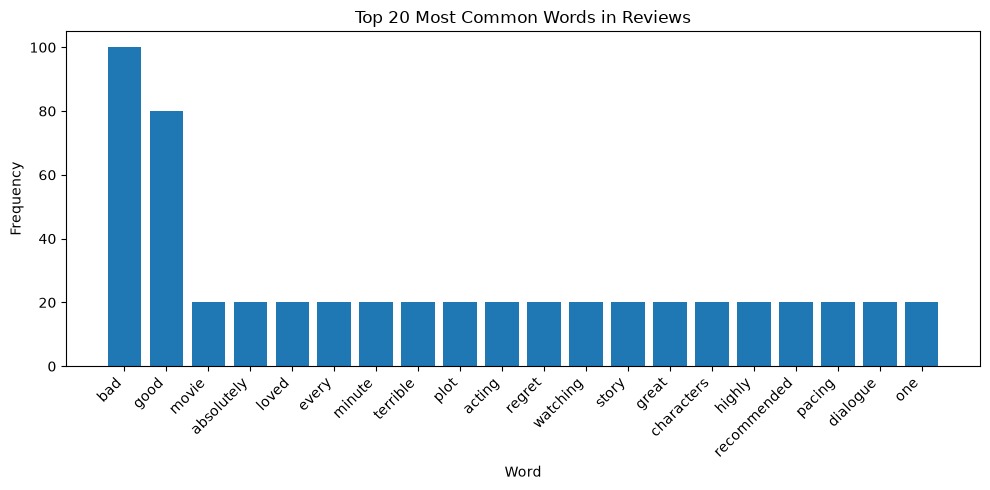

In [5]:
all_tokens = [t for tokens in df["tokens"] for t in tokens]
freq = Counter(all_tokens)
top_words = freq.most_common(20)

words, counts = zip(*top_words)
plt.figure(figsize=(10, 5))
plt.bar(words, counts)
plt.xticks(rotation=45, ha="right")
plt.title("Top 20 Most Common Words in Reviews")
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


### 5. Print the results of the analysis


In [6]:
print("--- Analysis Results ---")
print(f"Total reviews: {total_reviews}")
print(f"Average word count per review: {avg_word_count:.2f}")
print(f"Positive reviews (mention 'good'): {positive_reviews}")
print(f"Negative reviews (mention 'bad'): {negative_reviews}")
print(f"Top 10 words: {top_words[:10]}")


--- Analysis Results ---
Total reviews: 120
Average word count per review: 6.00
Positive reviews (mention 'good'): 80
Negative reviews (mention 'bad'): 80
Top 10 words: [('bad', 100), ('good', 80), ('movie', 20), ('absolutely', 20), ('loved', 20), ('every', 20), ('minute', 20), ('terrible', 20), ('plot', 20), ('acting', 20)]


## Task 2: N-gram Generation from Poem Data

Dataset: [Poem Classification (NLP) (Kaggle)](https://www.kaggle.com/datasets/shivamburnwal/poem-classification-nlp)

Download the CSV and place it next to this notebook as `poem_classification.csv`. If the file isn't found, a small demo sample is used instead.


### 1. Load the dataset from a CSV file


In [7]:
from nltk.util import ngrams

try:
    poems_df = pd.read_csv("poem_classification.csv")
    poem_col = "Poem" if "Poem" in poems_df.columns else poems_df.columns[0]
    print(f"Loaded {len(poems_df)} poems from poem_classification.csv")
except FileNotFoundError:
    print("poem_classification.csv not found locally - using a small demo sample instead.")
    poems_df = pd.DataFrame({
        "Poem": [
            "The sun sets slowly over the calm blue sea",
            "The moon rises over the calm blue sea at night",
            "Stars shine bright above the calm blue sea",
            "The wind blows softly over the calm blue sea",
            "Birds fly high above the calm blue sea today",
        ] * 10
    })
    poem_col = "Poem"

poems_df.head()


poem_classification.csv not found locally - using a small demo sample instead.


,Poem
0,The sun sets slowly over the calm blue sea
1,The moon rises over the calm blue sea at night
2,Stars shine bright above the calm blue sea
3,The wind blows softly over the calm blue sea
4,Birds fly high above the calm blue sea today


### 2. Pre-process the text data

- Tokenize the reviews into words
- Remove punctuation, and convert words to lowercase
- Remove common English stop words


In [8]:
poems_df["tokens"] = poems_df[poem_col].apply(preprocess)
poems_df[[poem_col, "tokens"]].head()


,Poem,tokens
0,The sun sets slowly over the calm blue sea,"[sun, sets, slowly, calm, blue, sea]"
1,The moon rises over the calm blue sea at night,"[moon, rises, calm, blue, sea, night]"
2,Stars shine bright above the calm blue sea,"[stars, shine, bright, calm, blue, sea]"
3,The wind blows softly over the calm blue sea,"[wind, blows, softly, calm, blue, sea]"
4,Birds fly high above the calm blue sea today,"[birds, fly, high, calm, blue, sea, today]"


### 3. Generate bi-grams (2-grams) from the preprocessed text data


In [9]:
poems_df["bigrams"] = poems_df["tokens"].apply(lambda toks: list(ngrams(toks, 2)))
poems_df[["tokens", "bigrams"]].head()


,tokens,bigrams
0,"[sun, sets, slowly, calm, blue, sea]","[(sun, sets), (sets, slowly), (slowly, calm), ..."
1,"[moon, rises, calm, blue, sea, night]","[(moon, rises), (rises, calm), (calm, blue), (..."
2,"[stars, shine, bright, calm, blue, sea]","[(stars, shine), (shine, bright), (bright, cal..."
3,"[wind, blows, softly, calm, blue, sea]","[(wind, blows), (blows, softly), (softly, calm..."
4,"[birds, fly, high, calm, blue, sea, today]","[(birds, fly), (fly, high), (high, calm), (cal..."


### 4. Calculate the frequency of each unique bi-gram in the "bigrams" column


In [10]:
all_bigrams = [bg for row in poems_df["bigrams"] for bg in row]
bigram_freq = Counter(all_bigrams)
len(bigram_freq)


18

### 5. Display the top 10 most common bi-grams


In [11]:
top_10_bigrams = bigram_freq.most_common(10)
for bg, count in top_10_bigrams:
    print(f"{bg}: {count}")


('calm', 'blue'): 50
('blue', 'sea'): 50
('sun', 'sets'): 10
('sets', 'slowly'): 10
('slowly', 'calm'): 10
('moon', 'rises'): 10
('rises', 'calm'): 10
('sea', 'night'): 10
('stars', 'shine'): 10
('shine', 'bright'): 10
